In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

import holidays

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import KNNImputer #agregado
from sklearn.pipeline import Pipeline #agregado

In [2]:
### carga datos de dataset en dataframe
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

In [3]:
### visualizacion de algunos datos
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

In [4]:
### Columnas, ¿cuáles son variables numéricas y cuales variables categóricas?
df.columns

Index(['key', 'date', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


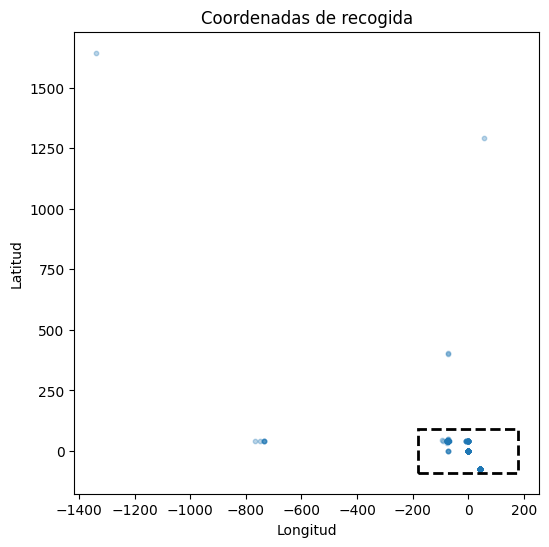

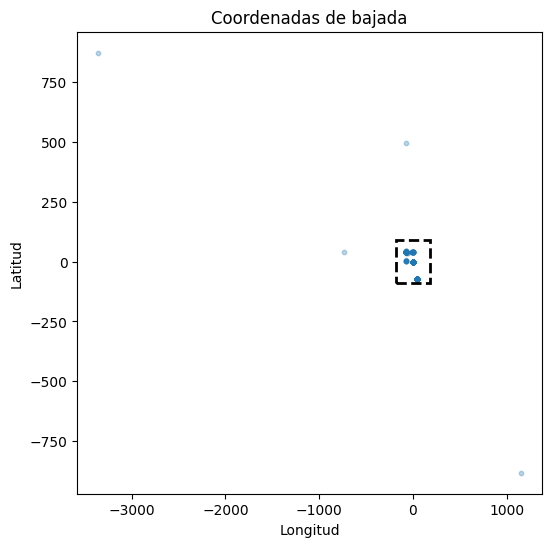

In [6]:
#Coordenadas de Pickup
plt.figure(figsize=(6,6))
plt.scatter(df["pickup_longitude"], df["pickup_latitude"], s=10, alpha=0.3)

world_rect = patches.Rectangle(
    (-180, -90),  
    360,          
    180,           
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
plt.gca().add_patch(world_rect)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida")
plt.show()

#Coordenadas de Dropoff
plt.figure(figsize=(6,6))
plt.scatter(df["dropoff_longitude"], df["dropoff_latitude"], s=10, alpha=0.3)

world_rect = patches.Rectangle(
    (-180, -90),  
    360,          
    180,           
    linewidth=2, edgecolor='black', facecolor='none', linestyle='--'
)
plt.gca().add_patch(world_rect)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Coordenadas de bajada")
plt.show()


***JUSTIFICACION DE POR QUE DROPEAMOS COORDENADAS INVALIDAS***

Primero validamos las coordenadas para evitar que valores inválidos generen distancias absurdas. Incluso dentro del rango [-90,90]/[-180,180]

In [7]:
#Coordenadas reales
lat_min, lat_max = -90, 90  
lon_min, lon_max = -180, 180

valid_pickup_lat = df["pickup_latitude"].between(lat_min, lat_max)
valid_pickup_lon = df["pickup_longitude"].between(lon_min, lon_max)
valid_dropoff_lat = df["dropoff_latitude"].between(lat_min, lat_max)
valid_dropoff_lon = df["dropoff_longitude"].between(lon_min, lon_max)

invalid_counts = (
    (~valid_pickup_lat).astype(int) +
    (~valid_pickup_lon).astype(int) +
    (~valid_dropoff_lat).astype(int) +
    (~valid_dropoff_lon).astype(int)
)

#Dropeamos filas con más de 1 coordenada inválida
df_filtrado = df[invalid_counts <= 1]


#Reemplazamos las coordenadas inválidas con NaN
df_filtrado.loc[~valid_pickup_lat, "pickup_latitude"] = np.nan
df_filtrado.loc[~valid_pickup_lon, "pickup_longitude"] = np.nan
df_filtrado.loc[~valid_dropoff_lat, "dropoff_latitude"] = np.nan
df_filtrado.loc[~valid_dropoff_lon, "dropoff_longitude"] = np.nan
df_filtrado.isna().sum()



 

key                  0
date                 0
fare_amount          0
pickup_datetime      0
pickup_longitude     6
pickup_latitude      2
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

Cantidad de valores negativos en fare_amount: 22
Porcentaje de valores negativos sobre el total de registros en fare_amount: 0.011000165002475037%


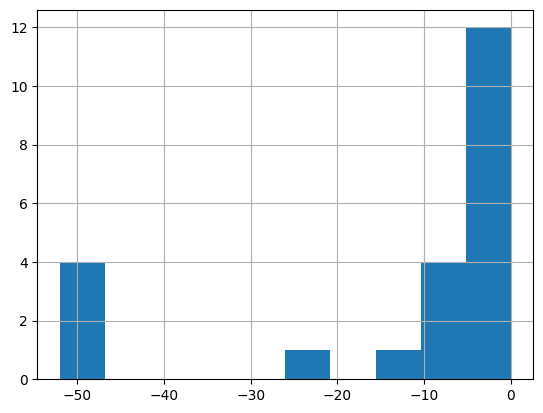

In [8]:
df_filtrado['fare_amount'].isnull().sum() #no hay nulos en fare_amount
df_filtrado[df_filtrado["fare_amount"] <= 0]["fare_amount"].hist()
negativos = df_filtrado[df_filtrado["fare_amount"] <= 0]['fare_amount'].size
print(f"Cantidad de valores negativos en fare_amount: {negativos}")
print(f"Porcentaje de valores negativos sobre el total de registros en fare_amount: {negativos / df_filtrado.fare_amount.size * 100}%")  # porcentaje de negativos en fare_amount
df_filtrado = df_filtrado[df_filtrado['fare_amount'] > 0]  # eliminamos los negativos y ceros


In [9]:
df_filtrado.shape

(199975, 9)

***AGREGAR JUSTIFICACION DE PORQUE BOLETEAMOS LOS NULOS***

<Axes: xlabel='distance_km'>

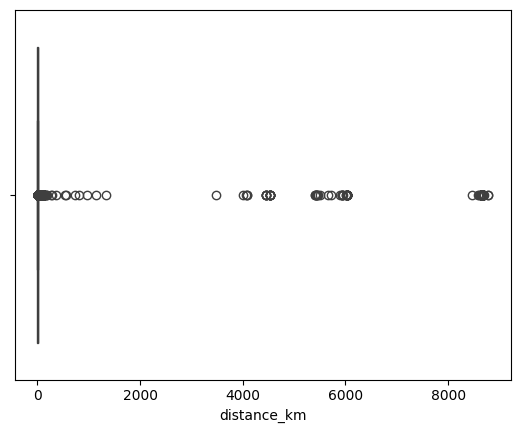

In [10]:
def haversine_km(lat1, lon1, lat2, lon2):
    # retorna distancia en kilómetros (vectorizado)
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


df_filtrado['distance_km'] = haversine_km(
    df_filtrado['pickup_latitude'], df_filtrado['pickup_longitude'],
    df_filtrado['dropoff_latitude'], df_filtrado['dropoff_longitude']
)

df_filtrado['distance_km'].describe()
sns.boxplot(x=df_filtrado['distance_km'])



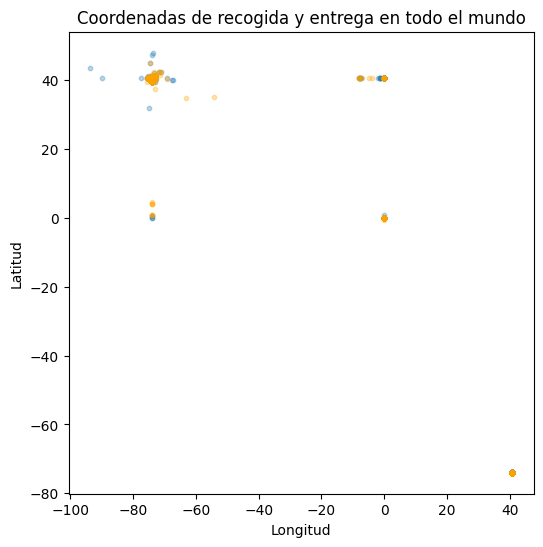

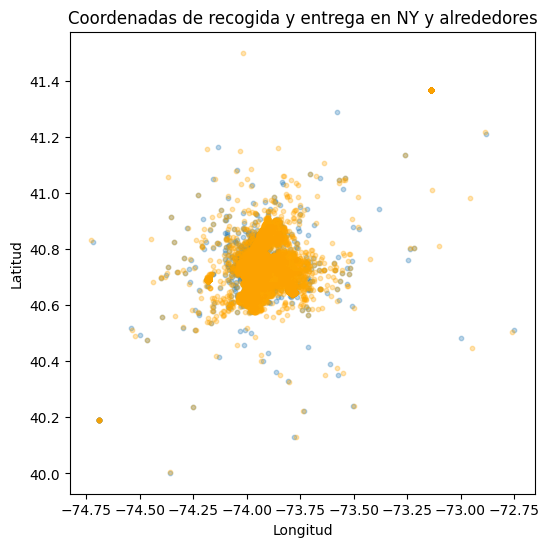

In [11]:
ny_coords = (
    (df_filtrado["pickup_latitude"].between(40, 42)| df_filtrado["pickup_latitude"].isna())&
    (df_filtrado["pickup_longitude"].between(-75, -72) | df_filtrado["pickup_longitude"].isna()) &
    (df_filtrado["dropoff_latitude"].between(40, 42) | df_filtrado["dropoff_latitude"].isna()) &
    (df_filtrado["dropoff_longitude"].between(-75, -72) | df_filtrado["dropoff_longitude"].isna())
)
df_filtrado_ny = df_filtrado[ny_coords].copy()
plt.figure(figsize=(6,6))
plt.scatter(df_filtrado["pickup_longitude"], df_filtrado["pickup_latitude"], s=10, alpha=0.3)
plt.scatter(df_filtrado["dropoff_longitude"], df_filtrado["dropoff_latitude"], s=10, alpha=0.3, color='orange')
plt.xlabel("Longitud")          
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida y entrega en todo el mundo")      
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(df_filtrado_ny["pickup_longitude"], df_filtrado_ny["pickup_latitude"], s=10, alpha=0.3)
plt.scatter(df_filtrado_ny["dropoff_longitude"], df_filtrado_ny["dropoff_latitude"], s=10, alpha=0.3, color='orange')
plt.xlabel("Longitud")          
plt.ylabel("Latitud")
plt.title("Coordenadas de recogida y entrega en NY y alrededores")      
plt.show()

In [12]:
df_filtrado_ny["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], errors="coerce", utc=True)

df_filtrado_ny["pickup_datetime"] = df_filtrado_ny["pickup_datetime"].dt.tz_convert("America/New_York")

us_holidays = holidays.US(years=df_filtrado_ny["pickup_datetime"].dt.year.unique(), state="NY")

df_filtrado_ny["is_holiday"] = df_filtrado_ny["pickup_datetime"].dt.date.isin(us_holidays).astype(int)


df_filtrado_ny["is_workday"] = (
    (df_filtrado_ny["pickup_datetime"].dt.dayofweek < 4) &  # lunes a jueves
    (~df_filtrado_ny["pickup_datetime"].dt.date.astype('datetime64[ns]').isin(us_holidays))  # feriado o fin de semana
).astype(int)

df_filtrado_ny[[ "is_holiday", "is_workday"]].value_counts()

# Extraer hora
df_filtrado_ny["hora_recogida"] = df_filtrado_ny["pickup_datetime"].dt.hour

df_filtrado_ny["mañana"] = (
    df_filtrado_ny["hora_recogida"].between(6, 11)
).astype(int)

df_filtrado_ny["tarde"] = (
    df_filtrado_ny["hora_recogida"].between(12, 19)
).astype(int)   

df_filtrado_ny["noche"] = (
    df_filtrado_ny["hora_recogida"].between(20, 23)
).astype(int)



df_modelo = df_filtrado_ny.drop(columns=["key", "hora_recogida", "pickup_datetime", "date"])

df_modelo["is_holiday"].value_counts()

C:\Users\Fabrote\AppData\Local\Temp\ipykernel_16960\568317027.py:12: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  (~df_filtrado_ny["pickup_datetime"].dt.date.astype('datetime64[ns]').isin(us_holidays))  # feriado o fin de semana


is_holiday
0    190063
1      5734
Name: count, dtype: int64

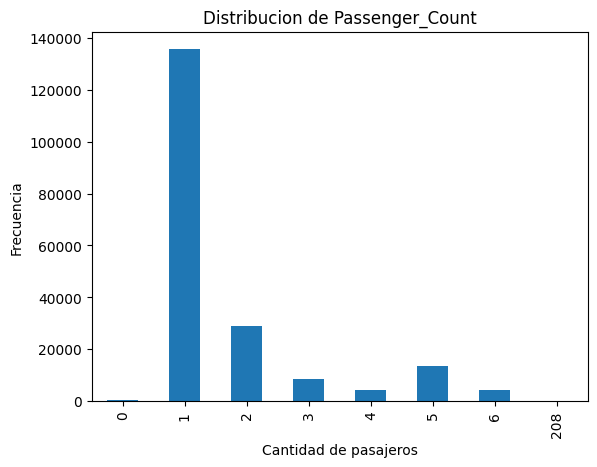

passenger_count
1      135491
2       28835
5       13722
3        8696
6        4184
4        4182
0         686
208         1
Name: count, dtype: int64

In [13]:
df_modelo["passenger_count"].value_counts().sort_index().plot(kind='bar')
plt.title("Distribucion de Passenger_Count")
plt.xlabel("Cantidad de pasajeros")
plt.ylabel("Frecuencia")
plt.show()
df_modelo["passenger_count"].value_counts()


In [14]:
### Creamos una nueva variable dummie con el tipo de viaje por pasajero 

df_modelo["uber_comun"] = df_modelo["passenger_count"].isin([1, 2, 3, 4]).astype(int)
df_modelo["uber_grande"] = df_modelo["passenger_count"].isin([5, 6]).astype(int)
#Convertimos el valor 208 en nulo 
df_modelo["passenger_count"] = df_modelo["passenger_count"].replace(208, np.nan)

Cantidad de viajes con distancia = 0: 2038

Estadísticas de fare_amount en viajes con distancia = 0:
count    2038.000000
mean       11.101305
std        14.647066
min         2.500000
25%         4.900000
50%         6.500000
75%        10.100000
max       200.000000
Name: fare_amount, dtype: float64


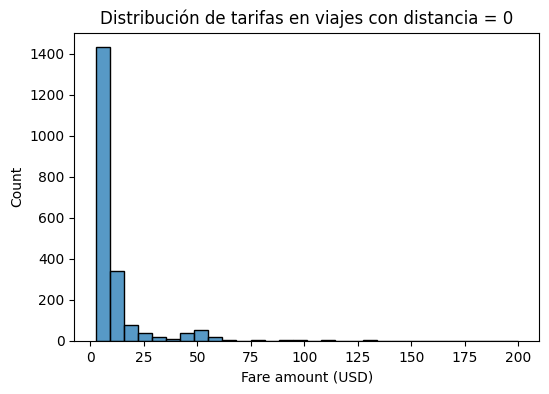

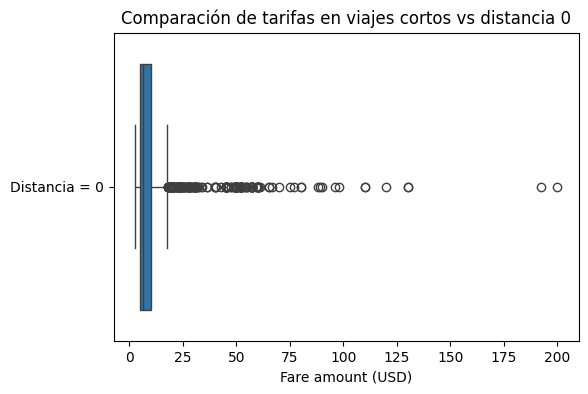

(1012,)

In [15]:
# 1. Contar cuántos viajes tienen distancia 0
zero_dist = df_modelo[df_modelo["distance_km"] == 0]
print("Cantidad de viajes con distancia = 0:", len(zero_dist))

# 2. Describir sus tarifas
print("\nEstadísticas de fare_amount en viajes con distancia = 0:")
print(zero_dist["fare_amount"].describe())

# 3. Histograma de esas tarifas
plt.figure(figsize=(6,4))
sns.histplot(zero_dist["fare_amount"], bins=30, kde=False)
plt.xlabel("Fare amount (USD)")
plt.title("Distribución de tarifas en viajes con distancia = 0")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(
    data=[zero_dist["fare_amount"]],
    orient="h"
)
plt.yticks([0], ["Distancia = 0"])
plt.xlabel("Fare amount (USD)")
plt.title("Comparación de tarifas en viajes cortos vs distancia 0")
plt.show()

zero_dist[zero_dist["fare_amount"] > 6.5]["fare_amount"].shape


De 2000 registros con distancia 0, graficamos y analizamos el target de cada uno, seleccionando como "precio base" hasta 6.5 USD, para tomar como válidos los viajes con distancia 0 y darle una mínima referencia al modelo. Quedaron dropeados 1012 y 925 dentro del dataset.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(df_modelo.drop(columns='fare_amount'), df_modelo['fare_amount'], test_size=0.2, random_state=42)


IMPUTACION DE VALORES FALTANTES EN COORDENADAS Y DISTANCIAS 
--------------------------------------------------------------

In [17]:
coords = ["pickup_latitude","pickup_longitude","dropoff_latitude","dropoff_longitude"]

invalidas = X_train[coords].isna().sum(axis=1)
filas_a_imputar = X_train[invalidas == 1].copy()


scaler = StandardScaler()
X_escaladas_train = scaler.fit_transform(filas_a_imputar[coords])

# 3️⃣ Imputación KNN en X_train
imputer = KNNImputer(n_neighbors=5)
X_imputadas_train = imputer.fit_transform(X_escaladas_train)

# 4️⃣ Volvemos a coordenadas originales en X_train
filas_a_imputar[coords] = scaler.inverse_transform(X_imputadas_train)

# 5️⃣ Reintegrar al X_train original
X_train.update(filas_a_imputar)

# 6️⃣ Imputación en X_test usando los mismos scaler e imputador
invalidas_test = X_test[coords].isna().sum(axis=1)
filas_a_imputar_test = X_test[invalidas_test == 1].copy()

# Escalar X_test con scaler ya ajustado
X_escaladas_test = scaler.transform(filas_a_imputar_test[coords])

# Imputar usando imputador ya ajustado
X_imputadas_test = imputer.transform(X_escaladas_test )

# Volvemos a coordenadas originales en X_test
filas_a_imputar_test[coords] = scaler.inverse_transform(X_imputadas_test)

# Reintegrar al X_test original
X_test.update(filas_a_imputar_test)



In [18]:
X_train['distance_km'] = haversine_km(
    X_train['pickup_latitude'], X_train['pickup_longitude'],
    X_train['dropoff_latitude'], X_train['dropoff_longitude']
)

X_test['distance_km'] = haversine_km(
    X_test['pickup_latitude'], X_test['pickup_longitude'],
    X_test['dropoff_latitude'], X_test['dropoff_longitude']
)
   

DROP DE COORDENADAS

In [19]:
##Dropeamos pickup_latitude y dropoff_latitude

X_train = X_train.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])
X_test  = X_test.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])

df_modelo = df_modelo.drop(columns=['pickup_latitude', 'dropoff_latitude', 'pickup_longitude', 'dropoff_longitude'])

IMPUTACION DE LOS VALORES DE FARE_AMOUNT DE LA DISTANCIA MENOR A 0,1


In [20]:
# Encontrar la moda SOLO en el train
zero_dist_train = y_train[X_train["distance_km"] < 0.1]
moda_fare_train = zero_dist_train.mode()[0]

# Imputar en train usando esa moda
y_train.loc[X_train["distance_km"] < 0.1] = moda_fare_train

# Imputar en test usando la MISMA moda del train (sin recalcular)
y_test.loc[X_test["distance_km"] < 0.1] = moda_fare_train






In [21]:
moda_fare_train

np.float64(2.5)

In [22]:
mask_train = X_train["distance_km"] < 0.1
mask_test  = X_test["distance_km"] < 0.1

# Antes de imputar, podés chequear cuántos casos hay:
print("Filas a imputar en train:", mask_train.sum())
print("Filas a imputar en test:", mask_test.sum())

# Aplicás la moda:
y_train.loc[mask_train] = moda_fare_train
y_test.loc[mask_test]   = moda_fare_train

Filas a imputar en train: 2533
Filas a imputar en test: 675


In [23]:
print("Valores únicos en train después de imputar:",
      y_train[mask_train].unique())
print("Valores únicos en test después de imputar:",
      y_test[mask_test].unique())

Valores únicos en train después de imputar: [2.5]
Valores únicos en test después de imputar: [2.5]


In [24]:
y_train[y_train > 300].sort_values(ascending=False)
y_test[y_test > 300].sort_values(ascending=False)

Series([], Name: fare_amount, dtype: float64)

IMPUTACION DE PASAJEROS POR LA MODA
-----------------------------------

In [25]:

##imputamos valor nulo de passenger_count por la moda
moda_passenger = X_train["passenger_count"].mode()[0]
X_train["passenger_count"].fillna(moda_passenger, inplace=True)
X_test["passenger_count"].fillna(moda_passenger, inplace=True)  
#Borro passenger_count porque ya tengo las dummies
X_train = X_train.drop(columns=['passenger_count'])
X_test  = X_test.drop(columns=['passenger_count'])
df_modelo = df_modelo.drop(columns=['passenger_count'])



C:\Users\Fabrote\AppData\Local\Temp\ipykernel_16960\1552015014.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["passenger_count"].fillna(moda_passenger, inplace=True)
C:\Users\Fabrote\AppData\Local\Temp\ipykernel_16960\1552015014.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves 

In [26]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

print("Train shape:", train.shape)
print("Test shape:", test.shape)






Train shape: (156637, 9)
Test shape: (39160, 9)


In [27]:

print("\n--- Estadísticas TRAIN ---")
print(train.describe(include="all").transpose())

print("\n--- Estadísticas TEST ---")
print(test.describe(include="all").transpose())


--- Estadísticas TRAIN ---
                count       mean       std   min       25%       50%  \
distance_km  156637.0   3.325664  3.756521  0.00  1.257801  2.157035   
is_holiday   156637.0   0.029374  0.168852  0.00  0.000000  0.000000   
is_workday   156637.0   0.548632  0.497631  0.00  0.000000  1.000000   
mañana       156637.0   0.287052  0.452388  0.00  0.000000  0.000000   
tarde        156637.0   0.432184  0.495381  0.00  0.000000  0.000000   
noche        156637.0   0.098457  0.297932  0.00  0.000000  0.000000   
uber_comun   156637.0   0.904844  0.293432  0.00  1.000000  1.000000   
uber_grande  156637.0   0.091619  0.288489  0.00  0.000000  0.000000   
fare_amount  156637.0  11.160157  9.470739  0.01  6.000000  8.500000   

                   75%        max  
distance_km   3.905281  115.07341  
is_holiday    0.000000    1.00000  
is_workday    1.000000    1.00000  
mañana        1.000000    1.00000  
tarde         1.000000    1.00000  
noche         0.000000    1.00000  

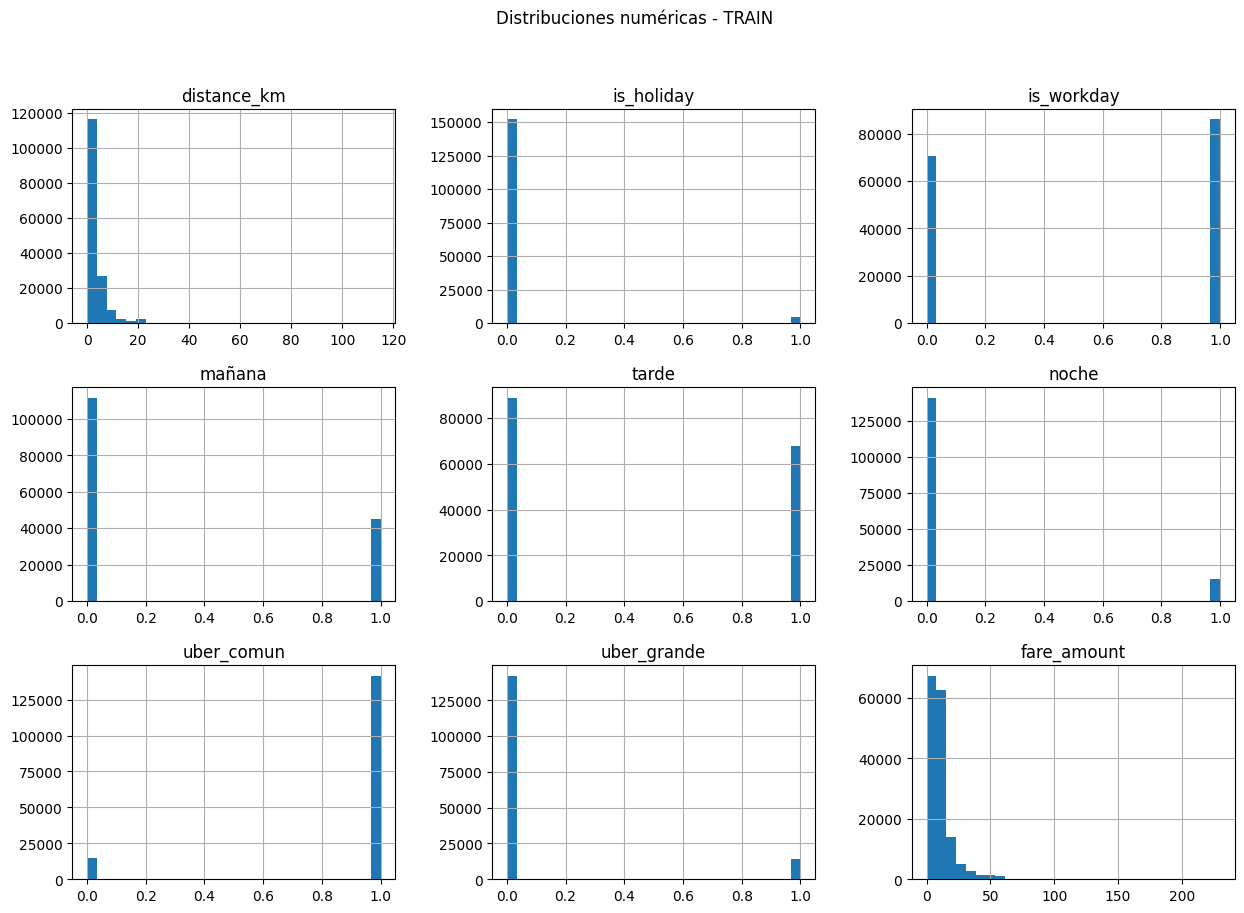

In [28]:
# Histogramas de variables numéricas
num_cols = train.select_dtypes(include=["int64", "float64"]).columns
train[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribuciones numéricas - TRAIN")
plt.show()

C:\Users\Fabrote\AppData\Local\Temp\ipykernel_16960\549040856.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(train[col], label="Train", shade=True)
C:\Users\Fabrote\AppData\Local\Temp\ipykernel_16960\549040856.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(test[col], label="Test", shade=True)


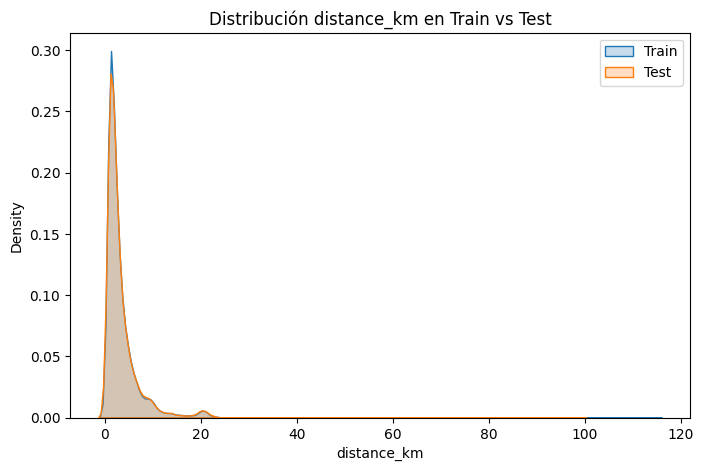

In [29]:

col = "distance_km"  # ejemplo, podés iterar con varias
plt.figure(figsize=(8,5))
sns.kdeplot(train[col], label="Train", shade=True)
sns.kdeplot(test[col], label="Test", shade=True)
plt.title(f"Distribución {col} en Train vs Test")
plt.legend()
plt.show()

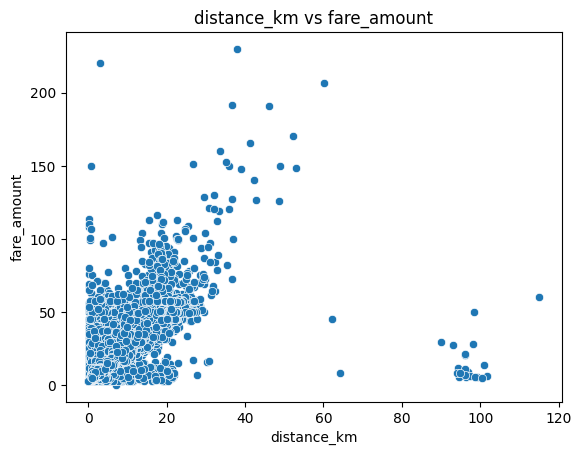

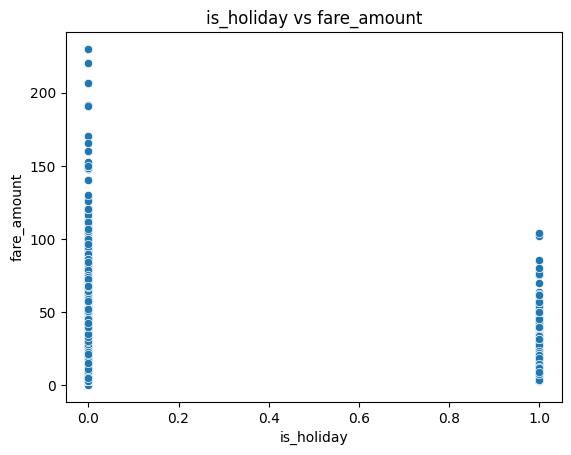

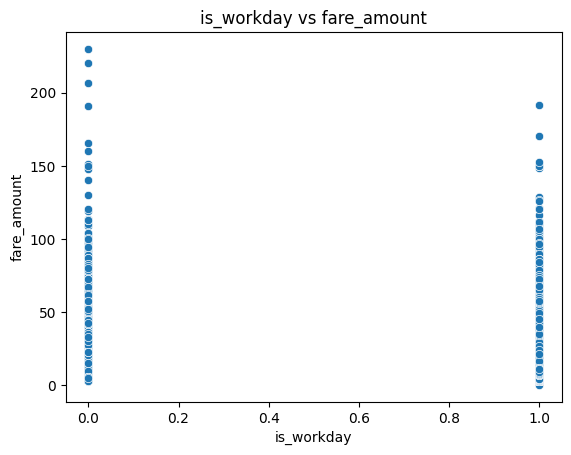

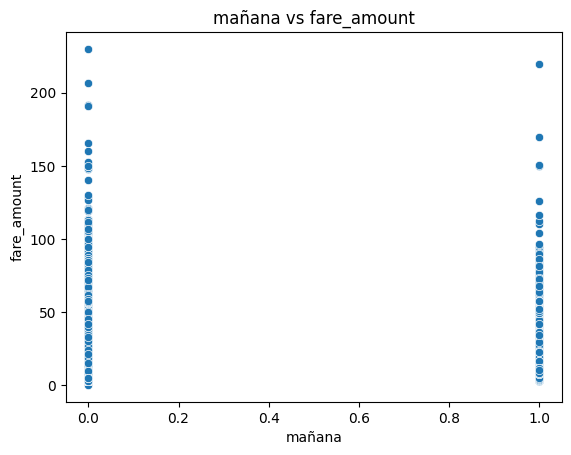

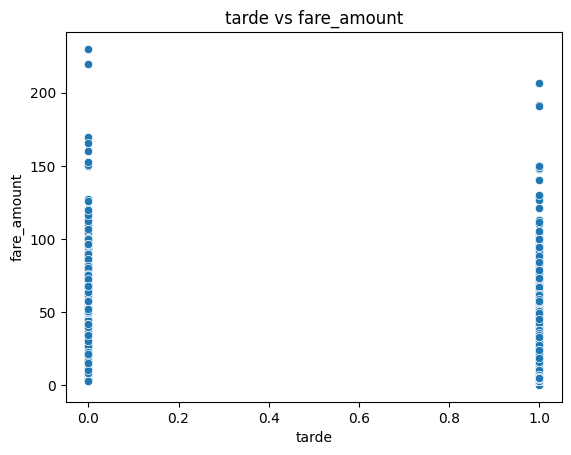

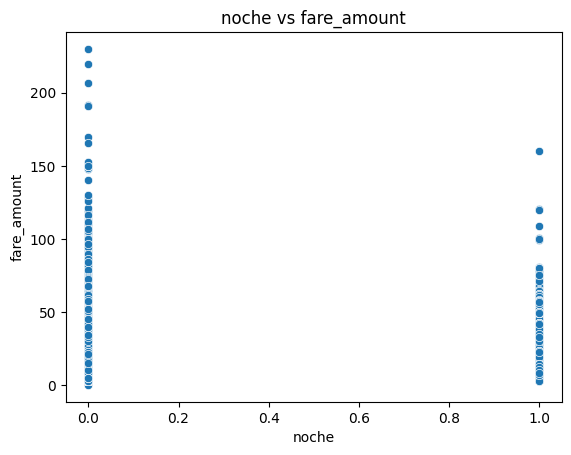

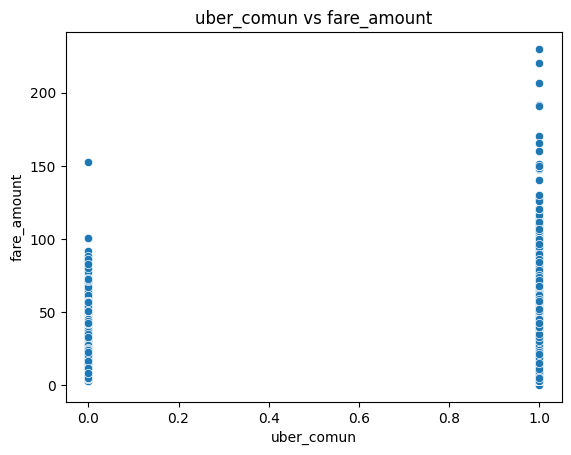

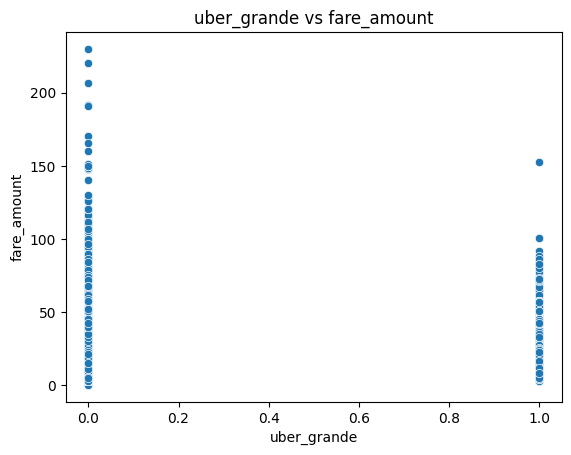

In [30]:
train = pd.concat([X_train, y_train], axis=1)
test = pd.concat([X_test, y_test], axis=1)

for c in num_cols:
    if c != y_train.name:  # no comparar target consigo mismo
        sns.scatterplot(x=train[c], y=train[y_train.name])
        plt.title(f"{c} vs {y_train.name}")
        plt.show()

***AGREGAR JUSTIFICACION DE QUE VAMOS A HACER CON EL OUTLIER***
No eliminamos filas innecesariamente y no inventamos datos arbitrarios. Usamos la moda porque refleja el valor más frecuente y es consistente con la realidad del dominio (viajes de 1 pasajero).

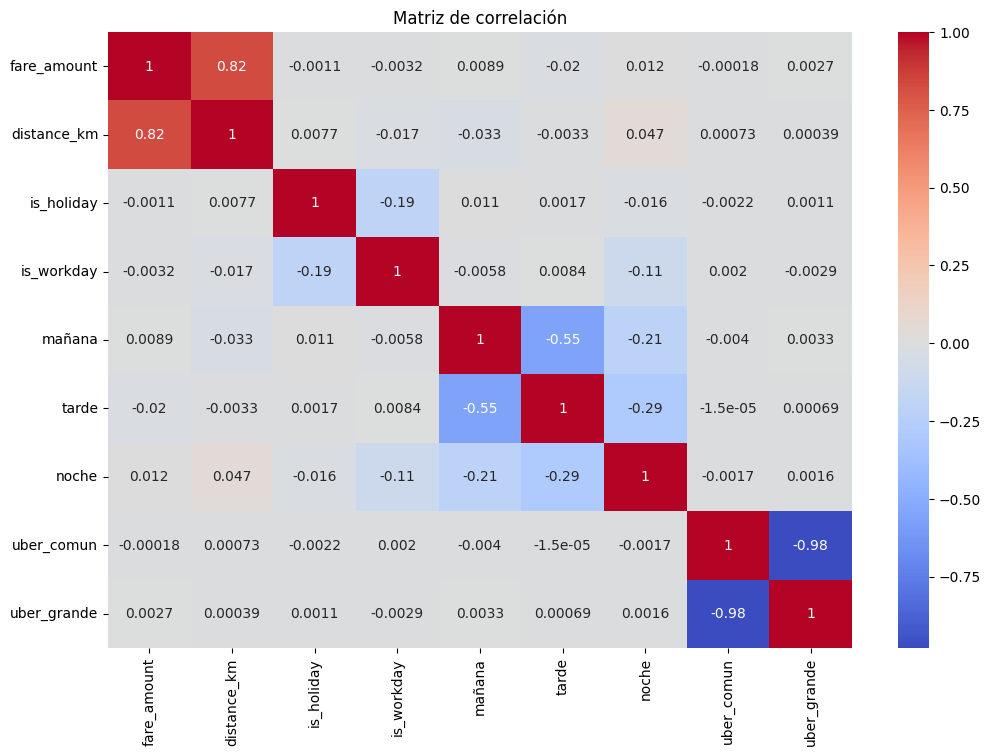

In [31]:
# Supongamos que tus features están en un DataFrame "df"
corr = df_modelo.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()


distance_km    0.00079
is_holiday     0.00000
is_workday     0.00000
mañana         0.00000
tarde          0.00000
noche          0.00000
uber_comun     1.00000
uber_grande    0.00000
Name: 170081, dtype: float64

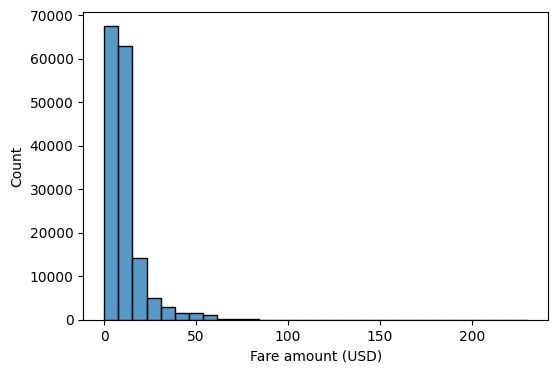

In [32]:
##histograma de fare_amount
plt.figure(figsize=(6,4))   
sns.histplot(y_train, bins=30, kde=False)
plt.xlabel("Fare amount (USD)")
##fare_amount mayores a 200
y_train[y_train > 200]
##ver fila del indice 170081
X_train.loc[170081]



In [33]:
from sklearn.compose import ColumnTransformer

num_cols = ["distance_km"]
cat_cols = ["is_holiday", "is_workday", "mañana", "tarde", "noche", "uber_comun", "uber_grande"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", "passthrough", cat_cols)  # deja las dummies como están
    ]
)
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [34]:
#imputar coordenadas con knn

pipe_lr = Pipeline([
    ("scaler", preprocessor),
    ("model", LinearRegression())
])

# Entrenamos el pipeline con training set
pipe_lr.fit(X_train, y_train)

# Predicciones sobre train y test
y_train_pred = pipe_lr.predict(X_train)
y_test_pred = pipe_lr.predict(X_test)

print("Entrenamiento:")
### RMSE calcular el RMSE
rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_train, y_train_pred))

print("\nPrueba:")
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_test_pred))



Entrenamiento:
RMSE: 4.795055158147808
R²: 0.7436565488485942

Prueba:
RMSE: 4.622287963768089
R²: 0.7685416716352672


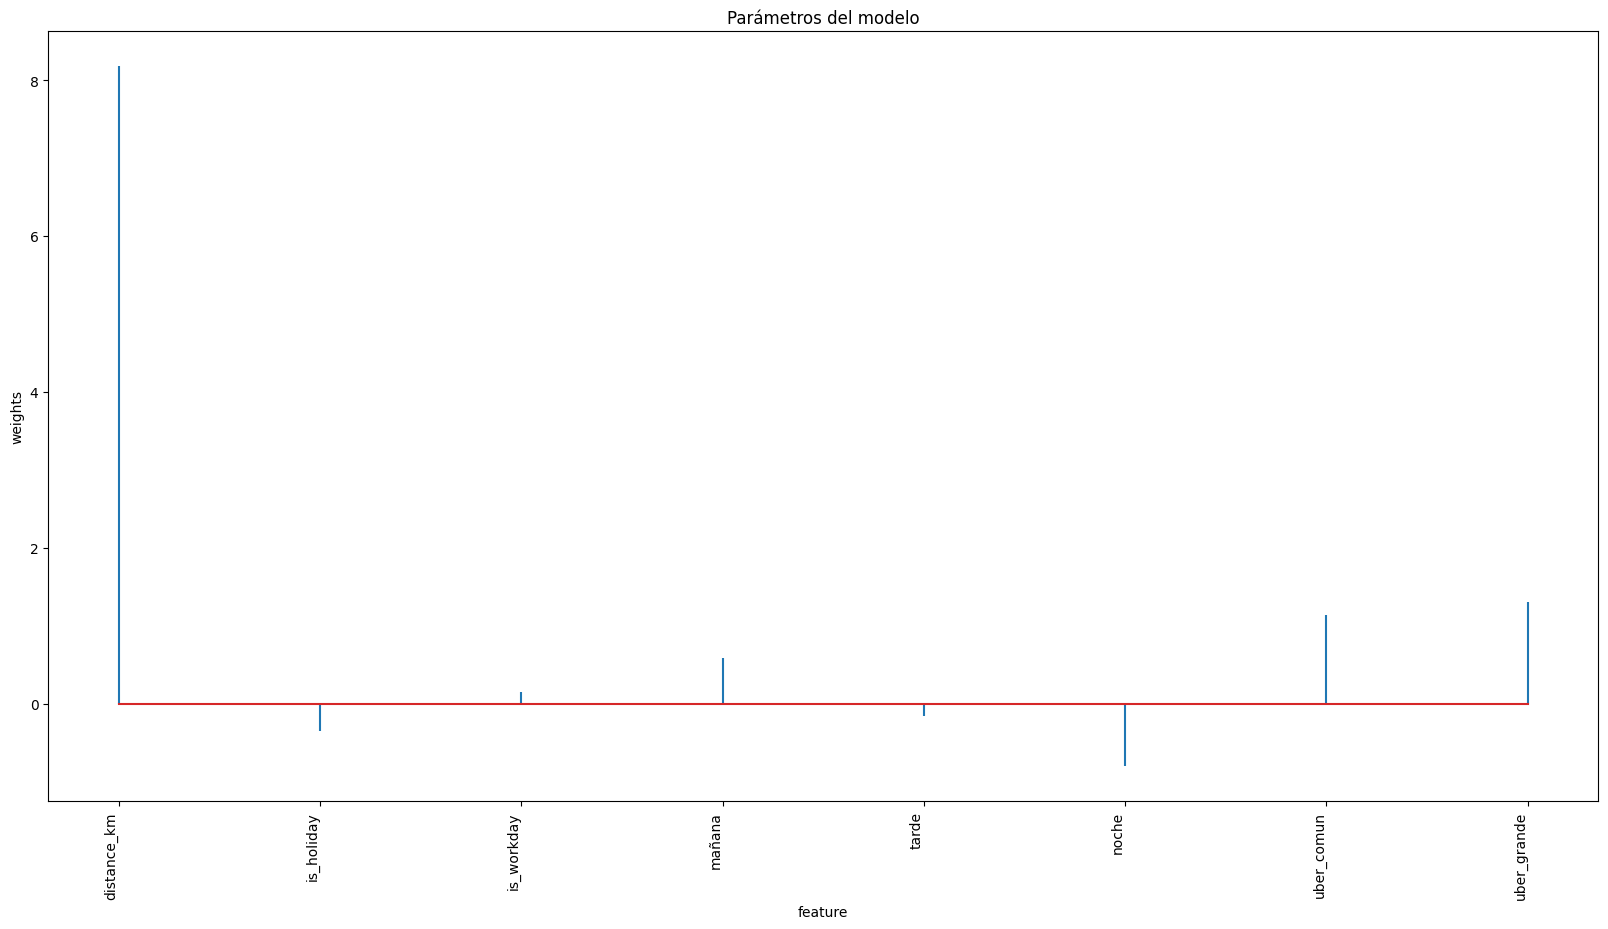

In [35]:
# Coeficientes del modelo

df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': pipe_lr.steps[1][1].coef_.flatten()}
                  )

fig, ax = plt.subplots(figsize=(20, 10))
ax.stem(df_coeficientes.predictor, df_coeficientes.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=10)
ax.set_xlabel('feature')
ax.set_ylabel('weights')
ax.set_title('Parámetros del modelo');

In [36]:
# Predicciones test

predicciones = pipe_lr.predict(X=X_test)
predicciones = predicciones.flatten()
predicciones[:10]

array([ 7.10176897,  8.38855181,  9.54013033,  8.60696754, 13.12613493,
       17.10463361, 25.86965069,  7.41761547,  7.08329791, 14.17912513])

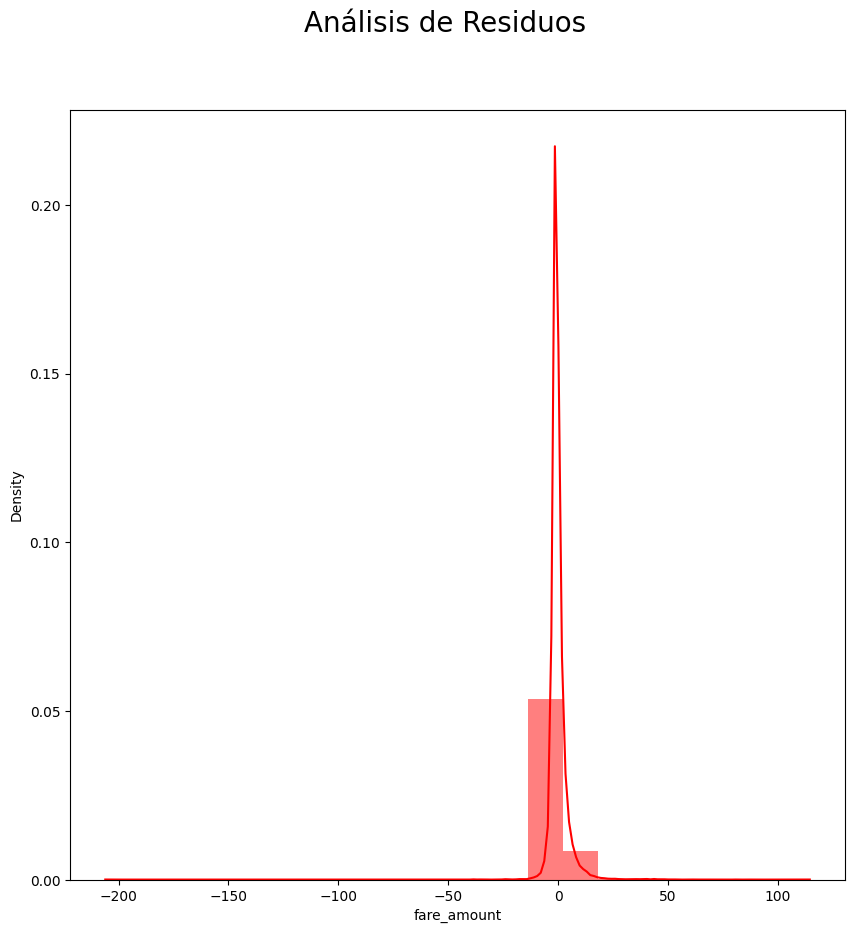

In [37]:
fig = plt.figure(figsize=(10,10))
  
sns.histplot((y_test - predicciones.reshape(y_test.shape)), color="red", kde=True, stat="density", linewidth=0,bins=20)
fig.suptitle('Análisis de Residuos', fontsize = 20)    
plt.show()

Se detectaron 482 outliers
     y_real     y_pred    residuo
6      4.10  25.869651 -21.769651
104    3.30  28.603761 -25.303761
129   89.80  53.777290  36.022710
189   49.57   6.221677  43.348323
477   33.83  19.747666  14.082334


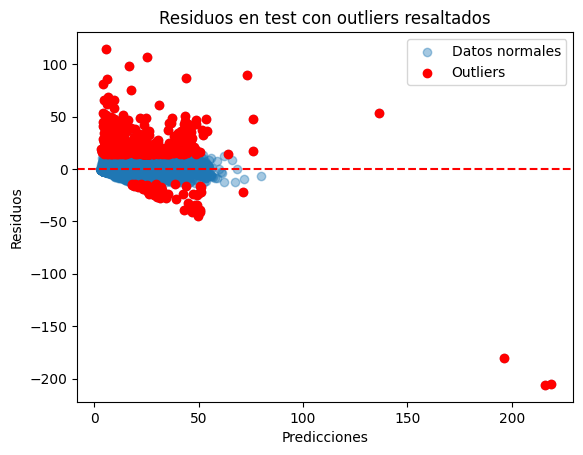

In [38]:

# Suponiendo que y_test y y_pred ya son numpy arrays o pandas Series
y_real = np.ravel(y_test)   # convierte a array 1D
y_pred = np.ravel(y_test_pred)   # convierte a array 1D

residuos = y_real - y_pred

# Calcular media y desvío estándar
mean_res = np.mean(residuos)
std_res = np.std(residuos)

# Definir umbral (3 sigmas)
umbral = 3 * std_res

# Detectar outliers
outliers_mask = np.abs(residuos - mean_res) > umbral
outliers = pd.DataFrame({
    "y_real": y_real,
    "y_pred": y_pred,
    "residuo": residuos
})[outliers_mask]

print(f"Se detectaron {outliers.shape[0]} outliers")
print(outliers.head())

# Gráfico con outliers resaltados
plt.scatter(y_pred, residuos, alpha=0.4, label="Datos normales")
plt.scatter(outliers["y_pred"], outliers["residuo"], color="red", label="Outliers")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.legend()
plt.title("Residuos en test con outliers resaltados")
plt.show()


In [39]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)  # solo X_train
X_val_scaled   = scaler.transform(X_val)        # usar mismo scaler
X_test_scaled  = scaler.transform(X_test)

In [40]:
X_train_scaled.shape, X_val_scaled.shape, X_test.shape

((137057, 8), (19580, 8), (39160, 8))

In [41]:
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


(137057,)
(19580,)
(39160,)


In [42]:
y_train = y_train.values.reshape(-1,1)
y_val   = y_val.values.reshape(-1,1)
y_test  = y_test.values.reshape(-1,1)


GRADIENTE DESCENDIENTE


Época 0/200 - Train MSE: 214.7648 - Val MSE: 210.5937
Época 10/200 - Train MSE: 25.4809 - Val MSE: 23.6628
Época 20/200 - Train MSE: 23.2693 - Val MSE: 21.3248
Época 30/200 - Train MSE: 23.2427 - Val MSE: 21.2806
Época 40/200 - Train MSE: 23.2421 - Val MSE: 21.2780
Época 50/200 - Train MSE: 23.2418 - Val MSE: 21.2775
Época 60/200 - Train MSE: 23.2416 - Val MSE: 21.2772
Época 70/200 - Train MSE: 23.2413 - Val MSE: 21.2770
Época 80/200 - Train MSE: 23.2411 - Val MSE: 21.2768
Época 90/200 - Train MSE: 23.2409 - Val MSE: 21.2766
Época 100/200 - Train MSE: 23.2407 - Val MSE: 21.2764
Época 110/200 - Train MSE: 23.2405 - Val MSE: 21.2762
Época 120/200 - Train MSE: 23.2404 - Val MSE: 21.2761
Época 130/200 - Train MSE: 23.2402 - Val MSE: 21.2759
Época 140/200 - Train MSE: 23.2401 - Val MSE: 21.2758
Época 150/200 - Train MSE: 23.2399 - Val MSE: 21.2757
Época 160/200 - Train MSE: 23.2398 - Val MSE: 21.2756
Época 170/200 - Train MSE: 23.2397 - Val MSE: 21.2755
Época 180/200 - Train MSE: 23.2396 - 

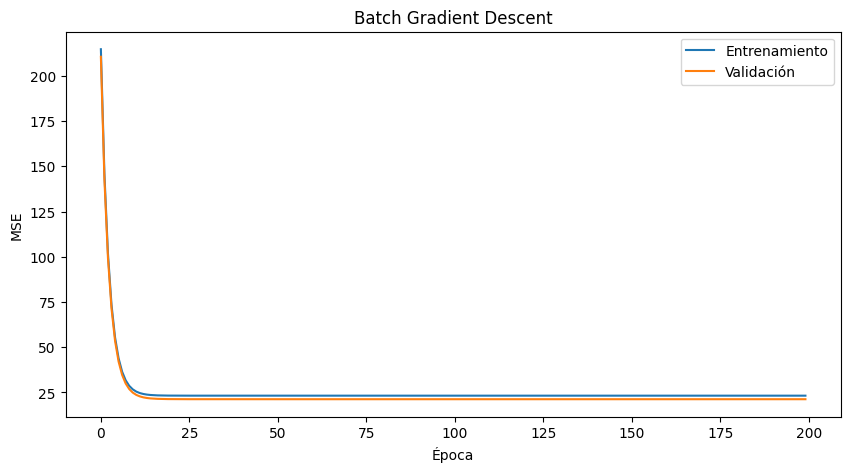

In [43]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.1, epochs=100, schedule=False):
    n, m = X_train.shape
    o = X_val.shape[0]

    # Agregar columna de unos (bias)
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val   = np.hstack((np.ones((o, 1)), X_val))

    # Asegurar vectores columna
    y_train = y_train.reshape(-1, 1)
    y_val   = y_val.reshape(-1, 1)

    # Inicializar pesos en cero
    W = np.zeros((m+1, 1))

    train_errors = []
    val_errors = []

    for ep in range(epochs):
        # Predicción entrenamiento
        pred_train = X_train @ W
        error_train = y_train - pred_train

        # MSE entrenamiento
        train_mse = np.mean(error_train**2)
        train_errors.append(train_mse)

        # Predicción validación
        pred_val = X_val @ W
        error_val = y_val - pred_val

        # MSE validación
        val_mse = np.mean(error_val**2)
        val_errors.append(val_mse)

        # Gradiente vectorizado: -(2/n) Xᵀ (y - XW)
        grad = -(2/n) * (X_train.T @ error_train)

        # Learning rate con schedule opcional
        lr_t = lr / np.sqrt(ep+1) if schedule else lr
        W -= lr_t * grad

        if ep % 10 == 0:
            print(f"Época {ep}/{epochs} - Train MSE: {train_mse:.4f} - Val MSE: {val_mse:.4f}")

    # Graficar
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(val_errors, label='Validación')
    plt.xlabel('Época')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Batch Gradient Descent')
    plt.show()

    return W



W_batch = gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.1, epochs=200)



Gradiente Estocástico


Época 1/20 - Train MSE: 106.2122 - Test MSE: 103.7441
Época 2/20 - Train MSE: 82.0838 - Test MSE: 79.9266
Época 3/20 - Train MSE: 68.3525 - Test MSE: 66.3497
Época 4/20 - Train MSE: 59.4409 - Test MSE: 57.5262
Época 5/20 - Train MSE: 53.0713 - Test MSE: 51.2119
Época 6/20 - Train MSE: 48.4542 - Test MSE: 46.6289
Época 7/20 - Train MSE: 45.0180 - Test MSE: 43.2119
Época 8/20 - Train MSE: 42.2248 - Test MSE: 40.4326
Época 9/20 - Train MSE: 39.7310 - Test MSE: 37.9473
Época 10/20 - Train MSE: 37.6809 - Test MSE: 35.9055
Época 11/20 - Train MSE: 35.9976 - Test MSE: 34.2281
Época 12/20 - Train MSE: 34.7102 - Test MSE: 32.9437
Época 13/20 - Train MSE: 33.5305 - Test MSE: 31.7654
Época 14/20 - Train MSE: 32.4169 - Test MSE: 30.6504
Época 15/20 - Train MSE: 31.4065 - Test MSE: 29.6351
Época 16/20 - Train MSE: 30.6008 - Test MSE: 28.8261
Época 17/20 - Train MSE: 29.8756 - Test MSE: 28.0959
Época 18/20 - Train MSE: 29.3944 - Test MSE: 27.6157
Época 19/20 - Train MSE: 28.8386 - Test MSE: 27.0578


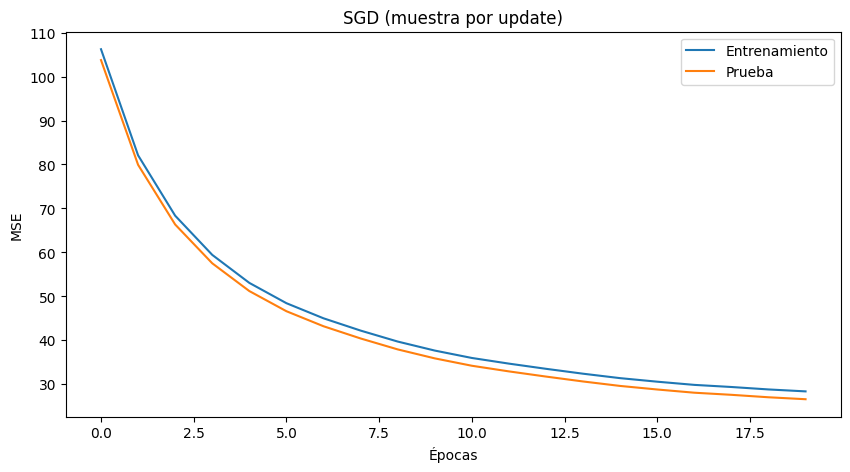

In [44]:
def stochastic_gradient_descent(
    X_train, y_train, X_test, y_test,
    lr=0.001, epochs=20, updates_per_epoch=10000, schedule=True
):
    n, m = X_train.shape

    # Agregar bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.zeros((m + 1, 1))  # pesos iniciales

    train_errors, test_errors = [], []
    t = 0  # contador de updates totales

    for ep in range(epochs):
        # indices aleatorios para elegir muestras
        idx = np.random.permutation(n)
        k = min(updates_per_epoch, n)   # límite de updates por época
        pick = idx[:k]

        for j in pick:
            x_sample = X_train[j:j+1]   # (1, m+1)
            y_sample = y_train[j:j+1]   # (1, 1)

            prediction = x_sample @ W
            error = y_sample - prediction

            gradient = -2 * (x_sample.T @ error)
            lr_t = lr / np.sqrt(t+1) if schedule else lr
            W -= lr_t * gradient
            t += 1

        # calcular errores por época
        train_pred = X_train @ W
        train_mse = np.mean((y_train - train_pred)**2)
        train_errors.append(train_mse)

        test_pred = X_test @ W
        test_mse = np.mean((y_test - test_pred)**2)
        test_errors.append(test_mse)

        print(f"Época {ep+1}/{epochs} - Train MSE: {train_mse:.4f} - Test MSE: {test_mse:.4f}")

    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(test_errors, label='Prueba')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('SGD (muestra por update)')
    plt.show()

    return W


# Ejecutar SGD
W_sgd = stochastic_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.001, epochs=20)


Mini batch

Época 1/20 - Train MSE: 47.9552 - Test MSE: 46.1353
Época 2/20 - Train MSE: 33.6387 - Test MSE: 31.8808
Época 3/20 - Train MSE: 28.6054 - Test MSE: 26.8308
Época 4/20 - Train MSE: 26.3087 - Test MSE: 24.5073
Época 5/20 - Train MSE: 25.1150 - Test MSE: 23.2879
Época 6/20 - Train MSE: 24.4457 - Test MSE: 22.5974
Época 7/20 - Train MSE: 24.0404 - Test MSE: 22.1737
Época 8/20 - Train MSE: 23.7895 - Test MSE: 21.9083
Época 9/20 - Train MSE: 23.6250 - Test MSE: 21.7315
Época 10/20 - Train MSE: 23.5149 - Test MSE: 21.6111
Época 11/20 - Train MSE: 23.4395 - Test MSE: 21.5272
Época 12/20 - Train MSE: 23.3879 - Test MSE: 21.4688
Época 13/20 - Train MSE: 23.3511 - Test MSE: 21.4262
Época 14/20 - Train MSE: 23.3238 - Test MSE: 21.3936
Época 15/20 - Train MSE: 23.3044 - Test MSE: 21.3698
Época 16/20 - Train MSE: 23.2900 - Test MSE: 21.3517
Época 17/20 - Train MSE: 23.2795 - Test MSE: 21.3384
Época 18/20 - Train MSE: 23.2714 - Test MSE: 21.3277
Época 19/20 - Train MSE: 23.2651 - Test MSE: 21.3190
Ép

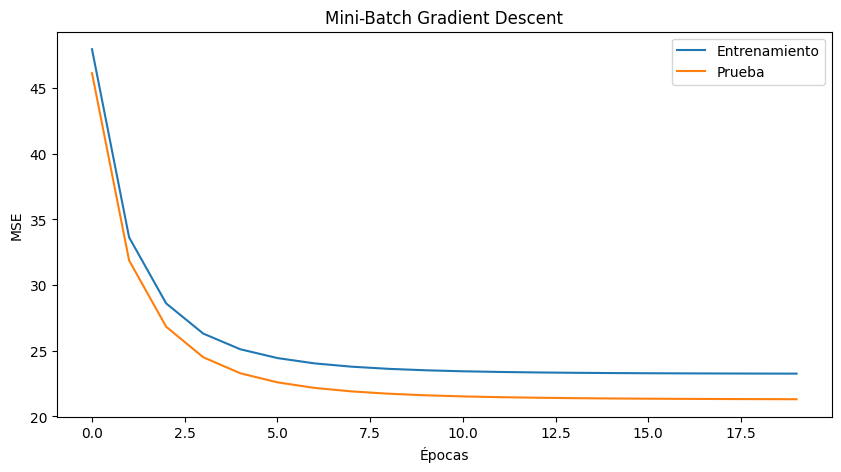

In [45]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test,
                                lr=0.01, epochs=20, batch_size=32, schedule=True):
    n, m = X_train.shape

    # Agregar bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test  = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    # Asegurar que y sean vectores columna
    y_train = y_train.reshape(-1, 1)
    y_test  = y_test.reshape(-1, 1)

    # Inicializar pesos
    W = np.zeros((m + 1, 1))

    train_errors, test_errors = [], []
    t = 0  # contador de updates

    for ep in range(epochs):
        # Permutar aleatoriamente
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        # Recorrer en lotes
        for j in range(0, n, batch_size):
            x_batch = X_train[j:j+batch_size]
            y_batch = y_train[j:j+batch_size]

            prediction = x_batch @ W
            error = y_batch - prediction

            gradient = -(2 / len(x_batch)) * (x_batch.T @ error)
            lr_t = lr / np.sqrt(t+1) if schedule else lr
            W -= lr_t * gradient
            t += 1

        # calcular errores globales por época
        train_mse = np.mean((y_train - (X_train @ W))**2)
        test_mse  = np.mean((y_test  - (X_test  @ W))**2)

        train_errors.append(train_mse)
        test_errors.append(test_mse)

        print(f"Época {ep+1}/{epochs} - Train MSE: {train_mse:.4f} - Test MSE: {test_mse:.4f}")

    # gráfico
    plt.figure(figsize=(10, 5))
    plt.plot(train_errors, label='Entrenamiento')
    plt.plot(test_errors, label='Prueba')
    plt.xlabel('Épocas')
    plt.ylabel('MSE')
    plt.legend()
    plt.title('Mini-Batch Gradient Descent')
    plt.show()

    return W


W_mini = mini_batch_gradient_descent(X_train_scaled, y_train, X_val_scaled, y_val, lr=0.01, epochs=20, batch_size=200)



REGULARIZACIÓN


RIDGE
---

In [46]:

modelo_ridge = RidgeCV(
    alphas=np.logspace(-10, 2, 200),
    cv=5,
    fit_intercept=True,
)
modelo_ridge.fit(X_train_scaled, y_train)

# Evaluar en el set de validación
y_val_pred = modelo_ridge.predict(X_val_scaled)
mse_val = mean_squared_error(y_val, y_val_pred)
print("MSE en validación:", mse_val)


MSE en validación: 21.275767494822126


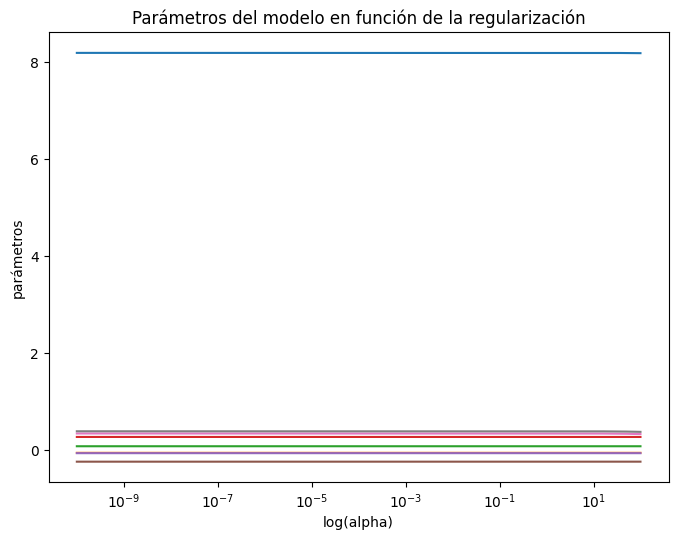

In [47]:

alphas = modelo_ridge.alphas
coefs = []

for alpha in alphas:
    modelo_temp = Ridge(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coefs.append(modelo_temp.coef_.flatten())

fig, ax = plt.subplots(figsize=(8, 5.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('log(alpha)')
ax.set_ylabel('parámetros')
ax.set_title('Parámetros del modelo en función de la regularización');
plt.axis('tight')
plt.show()

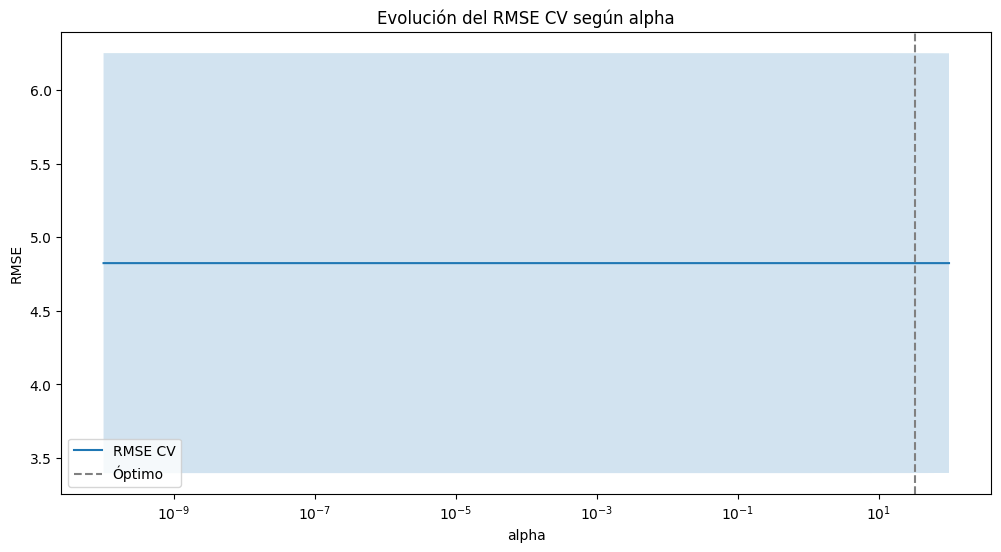

In [48]:
from sklearn.model_selection import KFold, cross_val_score

alphas = np.logspace(-10, 2, 200)
rmse_mean = []
rmse_std  = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for alpha in alphas:
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    
    # cross_val_score devuelve score (por defecto R^2), usamos scoring="neg_mean_squared_error"
    mse_scores = -cross_val_score(ridge, X_train_scaled, y_train,
                                  cv=kf,
                                  scoring="neg_mean_squared_error")
    
    rmse_mean.append(np.sqrt(mse_scores.mean()))
    rmse_std.append(np.sqrt(mse_scores.std()))

rmse_mean = np.array(rmse_mean)
rmse_std  = np.array(rmse_std)

# Alpha óptimo
optimo = alphas[np.argmin(rmse_mean)]

# Gráfico
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(alphas, rmse_mean, label="RMSE CV")
ax.fill_between(alphas, rmse_mean - rmse_std, rmse_mean + rmse_std, alpha=0.2)
ax.axvline(optimo, linestyle="--", color="gray", label="Óptimo")
ax.set_xscale('log')
ax.set_xlabel("alpha")
ax.set_ylabel("RMSE")
ax.set_title("Evolución del RMSE CV según alpha")
ax.legend()
plt.show()

In [49]:
print(f"Mejor valor de alpha encontrado: {modelo_ridge.alpha_}")

Mejor valor de alpha encontrado: 75.7525025877192


In [50]:
predicciones = modelo_ridge.predict(X = X_test_scaled)
predicciones = predicciones.flatten()
predicciones[:10]

array([ 7.12167273,  8.38793   ,  9.5661517 ,  8.62794875, 13.13070016,
       17.09906925, 25.84176988,  7.44162487,  7.08599939, 14.16866984])

In [51]:
import sklearn.metrics as metrics
R2 = metrics.r2_score(y_test, predicciones)
R2

0.7683936232182221

0.7421206663211961


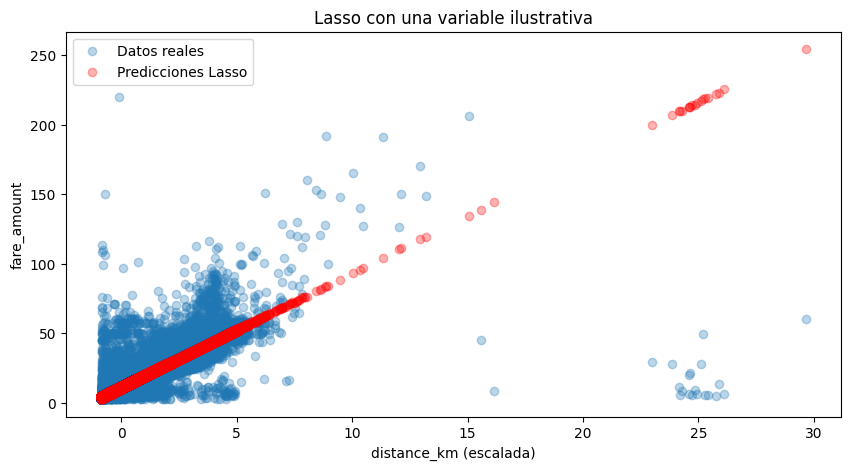

In [52]:
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)
print(lasso.score(X_train_scaled,np.array(y_train).reshape(-1,1)))
##Graficar los coeficientes
# Supongamos que la columna 5 es 'distance_km'
i = 0

plt.figure(figsize=(10,5))
plt.scatter(X_train_scaled[:, i], y_train, alpha=0.3, label='Datos reales')
plt.scatter(X_train_scaled[:, i], lasso.predict(X_train_scaled), 
            color='red', alpha=0.3, label='Predicciones Lasso')
plt.xlabel("distance_km (escalada)")
plt.ylabel("fare_amount")
plt.title("Lasso con una variable ilustrativa")
plt.legend()
plt.show()


R² en train: 0.7415773057526942


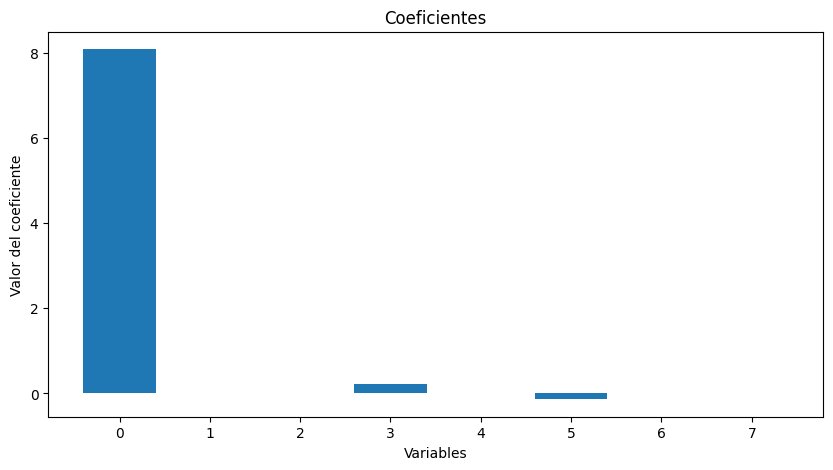

In [53]:

lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

print("R² en train:", lasso.score(X_train_scaled, y_train))

# Graficar coeficientes con nombres de variables
plt.figure(figsize=(10, 5))
plt.bar(range(len(lasso.coef_)), lasso.coef_)
plt.xlabel("Variables")
plt.ylabel("Valor del coeficiente")
plt.title("Coeficientes")
plt.show()


LASSO
---

Mejor alpha encontrado: 4.150404757850481e-05


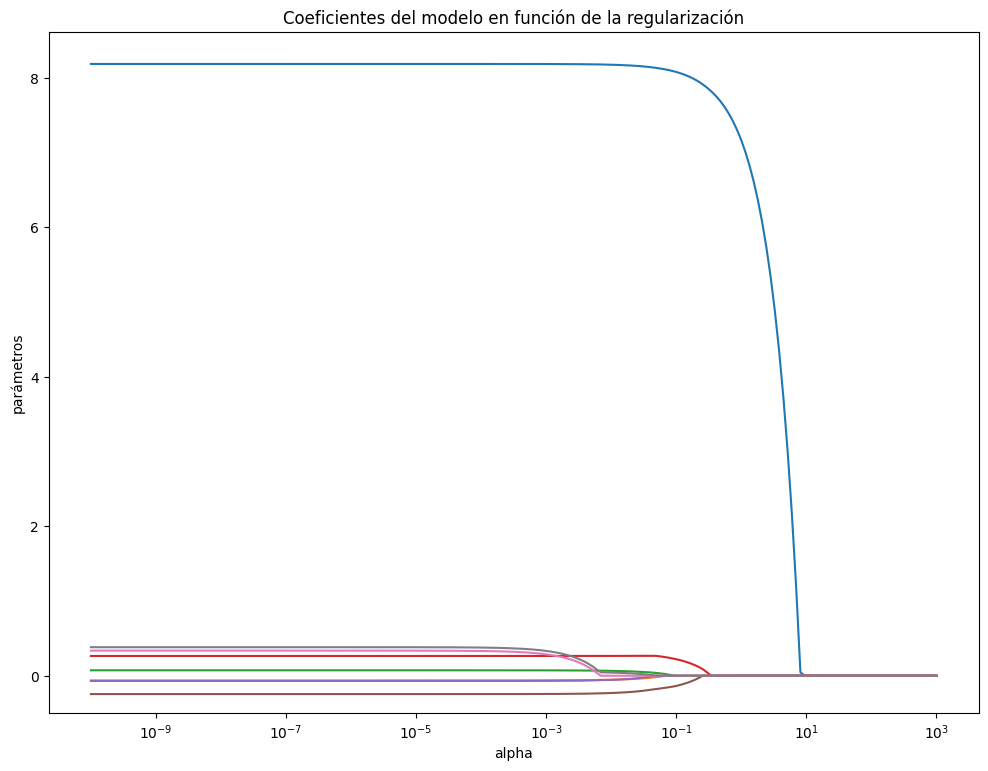

In [ ]:
from sklearn.linear_model import lasso_path
modelo = LassoCV(alphas=np.logspace(-10, 3, 200), cv=10)
modelo.fit(X_train_scaled, y_train.flatten())           #TODAVIA ME FALTA REPASAR DONDE VA X_VAL_SCALED
print("Mejor alpha encontrado:", modelo.alpha_)

# Usar lasso_path para obtener coeficientes en un rango de alphas
alphas_lasso, coefs_lasso, _ = lasso_path(X_train_scaled, y_train.flatten(), alphas=np.logspace(-10, 3, 200))

# Graficar
fig, ax = plt.subplots(figsize=(12, 8.84))
ax.plot(alphas_lasso, coefs_lasso.T)   # transponer para graficar cada coef
ax.set_xscale('log')
ax.set_ylim([-0.5, None])
ax.set_xlabel('alpha')
ax.set_ylabel('parámetros')
ax.set_title('Coeficientes del modelo en función de la regularización')
plt.show()




lo de abajo tarda muchisimo
---


Text(0.5, 1.0, 'Features incluidas en función de la regularización')

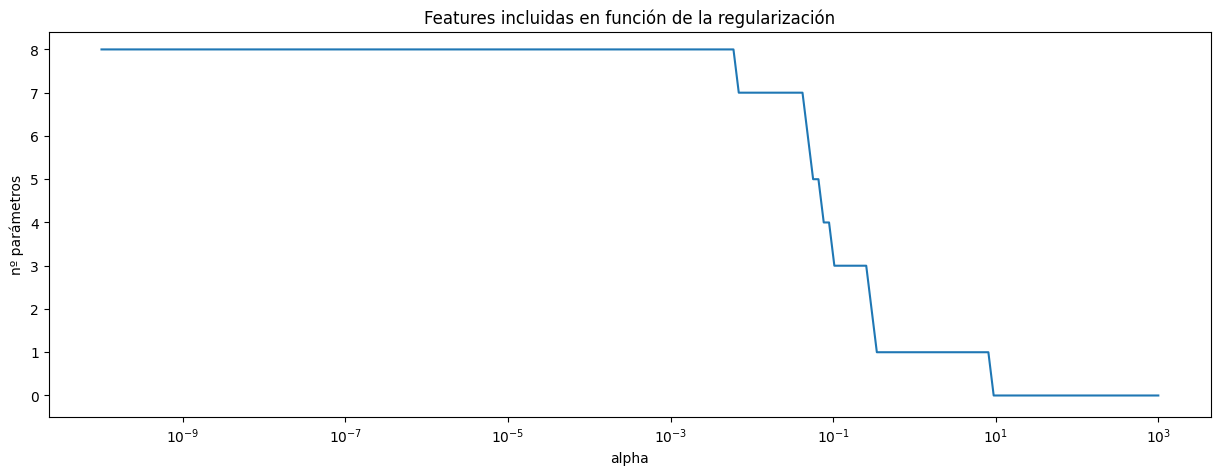

In [55]:
alphas = modelo.alphas_
n_predictores = []

for alpha in alphas:
    modelo_temp = Lasso(alpha=alpha, fit_intercept=False)
    modelo_temp.fit(X_train_scaled, y_train)
    coef_no_cero = np.sum(modelo_temp.coef_.flatten() != 0)
    n_predictores.append(coef_no_cero)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-0.5,None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº parámetros')
ax.set_title('Features incluidas en función de la regularización')

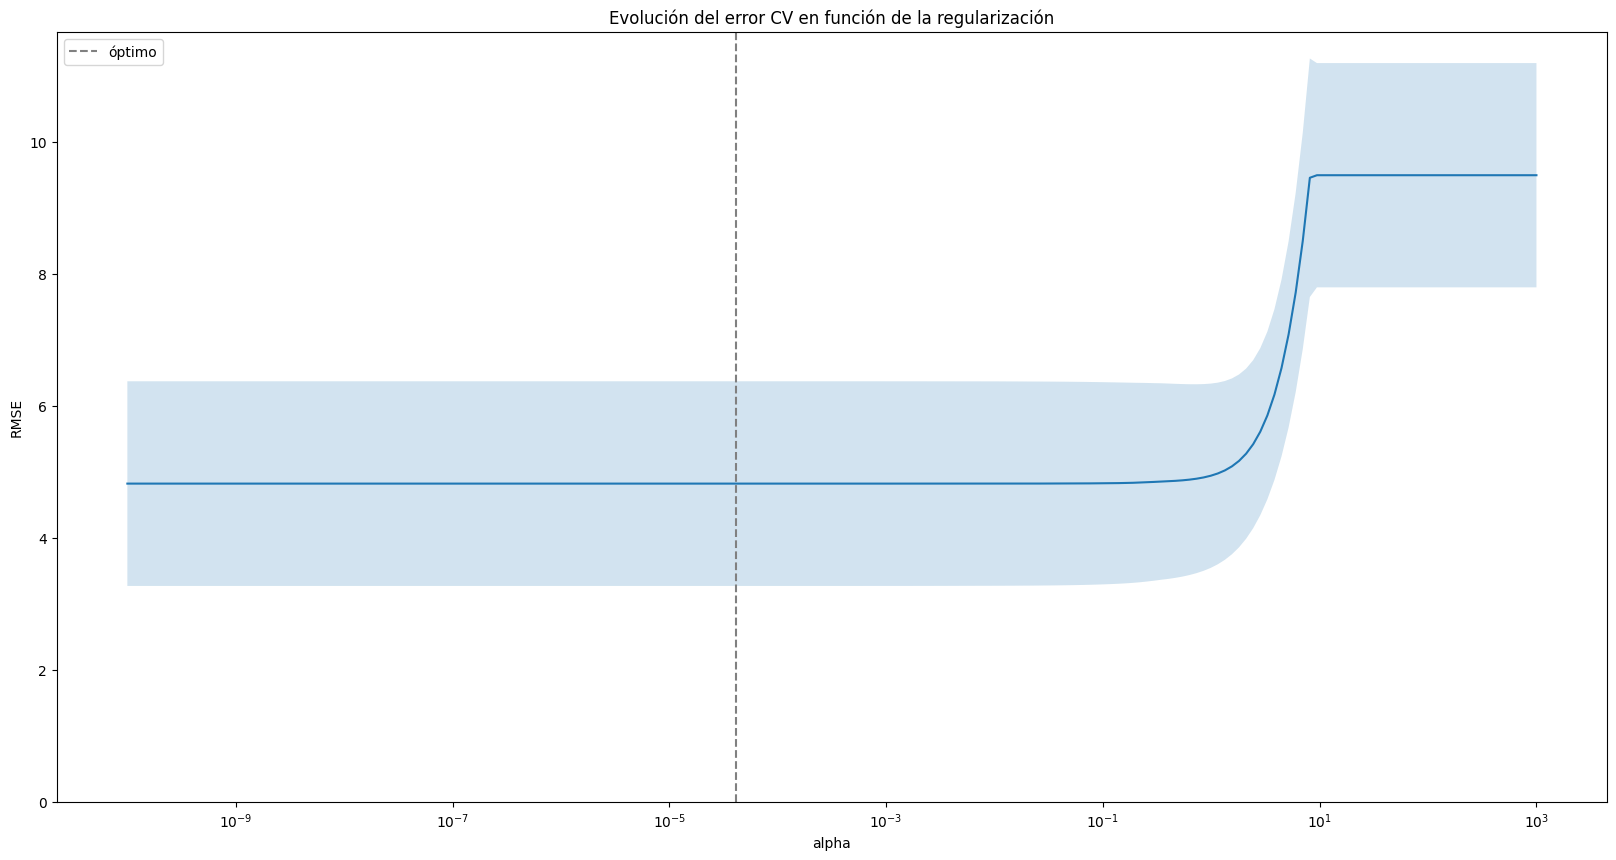

In [56]:
# Evolución del error de validación cruzada en función de alpha

mse_cv = modelo.mse_path_.mean(axis=1)
mse_sd = modelo.mse_path_.std(axis=1)

# Se aplica la raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# Se identifica el óptimo y el óptimo + 1std
min_rmse     = np.min(rmse_cv)
optimo       = modelo.alphas_[np.argmin(rmse_cv)]

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(modelo.alphas_, rmse_cv)
ax.fill_between(
    modelo.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)

ax.axvline(
    x         = optimo,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)

ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()

In [57]:
print(f"Mejor valor de alpha encontrado: {modelo.alpha_}")

Mejor valor de alpha encontrado: 4.150404757850481e-05


In [58]:
df_coeficientes = pd.DataFrame(
                        {'predictor': X_train.columns,
                         'coef': modelo.coef_.flatten()}
                  )

df_coeficientes[df_coeficientes.coef != 0]

,predictor,coef
0,distance_km,8.187118
1,is_holiday,-0.062051
2,is_workday,0.073116
3,mañana,0.264938
4,tarde,-0.069556
5,noche,-0.245111
6,uber_comun,0.334298
7,uber_grande,0.380200


In [ ]:
predicciones_lasso = modelo.predict(X=X_test_scaled) #Hacerlo con el x_val_scaled para ver el error en validación?
predicciones_lasso = predicciones_lasso.flatten()
predicciones_lasso[:10]

array([ 7.11960357,  8.38655844,  9.56583459,  8.62670961, 13.13192855,
       17.10247534, 25.84997366,  7.43973472,  7.08391337, 14.17047399])

In [60]:
R2 = metrics.r2_score(y_test, predicciones_lasso)
R2

0.768426755309293

ELASTIC NET 
---


In [ ]:
modelo_elast = ElasticNetCV(
            l1_ratio        = [0.1, 0.5, 0.9], #Tuve que cambiar esto del original
            alphas          = np.logspace(-4, 2, 100), #Esto tambien
            cv              = 5,
            max_iter        = 10000
         )
_ = modelo_elast.fit(X = X_train_scaled, y = y_train.flatten())


print("Mejor alpha:", modelo_elast.alpha_)
print("Mejor l1_ratio:", modelo_elast.l1_ratio_)

Mejor alpha: 0.0006135907273413176
Mejor l1_ratio: 0.1


In [70]:
from sklearn.metrics import mean_squared_error

# Predicciones con los mejores parámetros
pred = modelo_elast.predict(X_val_scaled)

# RMSE
rmse = np.sqrt(mean_squared_error(y_val, pred))
print("Alpha óptimo:", modelo_elast.alpha_)
print("L1_ratio óptimo:", modelo_elast.l1_ratio_)
print("RMSE en validación:", rmse)


Alpha óptimo: 0.0006135907273413176
L1_ratio óptimo: 0.1
RMSE en validación: 4.6125676365858865


In [71]:
pred_val = modelo_elast.predict(X_val_scaled)
pred_val = pred_val.flatten()

In [72]:
R2 = metrics.r2_score(y_test, pred_val)
R2

ValueError: Found input variables with inconsistent numbers of samples: [39160, 19580]

HICE HASTA LO DE ARRIBA
--------


----------------------------------------------------------------------------------------------------------------

0.7421218518870001


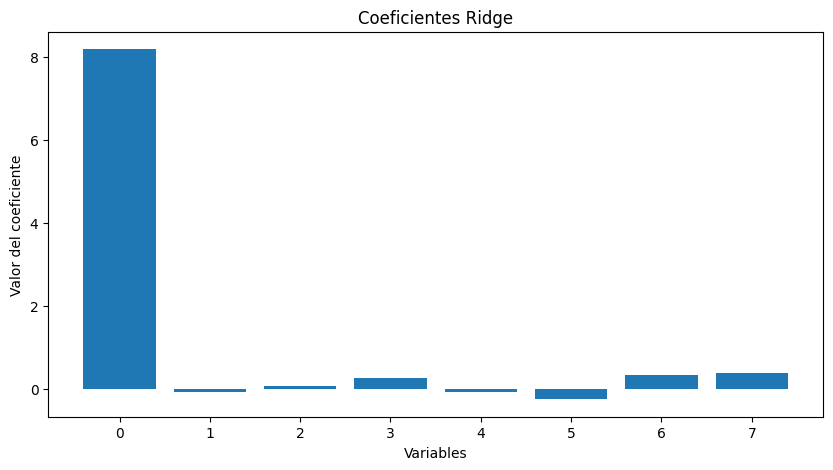

In [ ]:
##RIDGE
ridge = Ridge(alpha=0.001)
ridge.fit(X_train_scaled, y_train)  
print(ridge.score(X_train_scaled,np.array(y_train).reshape(-1,1)))
# Graficar coeficientes con nombres de variables
plt.figure(figsize=(10, 5))
plt.bar(range(len(ridge.coef_)), ridge.coef_)
plt.xlabel("Variables")
plt.ylabel("Valor del coeficiente")
plt.title("Coeficientes Ridge")
plt.show()
 

0.7421211103475753


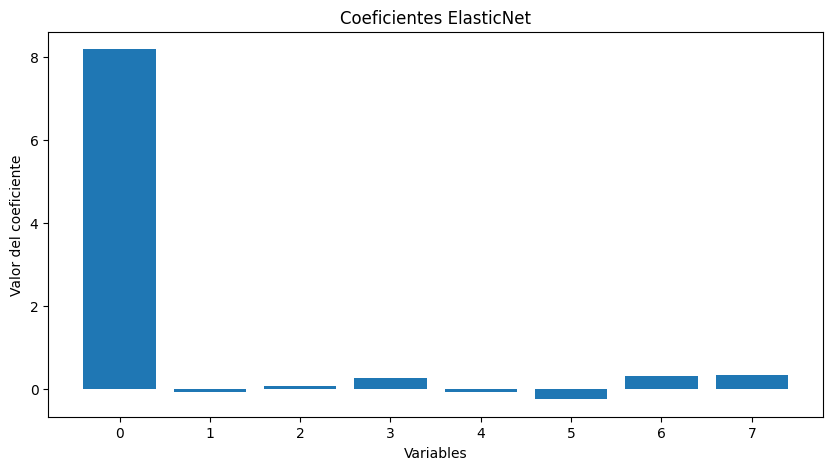

In [ ]:
##ElasticNet
elastic_net = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
elastic_net.fit(X_train_scaled, y_train)    
print(elastic_net.score(X_train_scaled,np.array(y_train).reshape(-1,1)))
# Graficar coeficientes con nombres de variables
plt.figure(figsize=(10, 5))
plt.bar(range(len(elastic_net.coef_)), elastic_net.coef_)
plt.xlabel("Variables")
plt.ylabel("Valor del coeficiente")
plt.title("Coeficientes ElasticNet")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.utils import resample

# Submuestreo para acelerar (ejemplo: 5000 filas aleatorias)
X_small, y_small = resample(X_train_scaled, y_train.to_numpy().ravel(), 
                            n_samples=5000, random_state=42)

# Rango de alphas más chico
alphas = np.logspace(-4, 2, 20)

coefs_ridge, coefs_lasso = [], []

for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=False)
    ridge.fit(X_small, y_small)
    coefs_ridge.append(ridge.coef_)
    
    lasso = Lasso(alpha=a, fit_intercept=False, max_iter=2000)
    lasso.fit(X_small, y_small)
    coefs_lasso.append(lasso.coef_)

# --- Gráfico comparativo ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Ridge
axes[0].plot(alphas, coefs_ridge)
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha (log)")
axes[0].set_ylabel("Coeficientes")
axes[0].set_title("Ridge: coeficientes vs regularización")

# Lasso
axes[1].plot(alphas, coefs_lasso)
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (log)")
axes[1].set_title("Lasso: coeficientes vs regularización")

plt.tight_layout()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'